# Baseline Model

Using a standard U-Net with ResNet18 trained on ImageNet as the pretrained encoder.

ResNet18-Encoder U-Net (pretrained variant)
======================================================================
Baseline for the scratch-built Baby U-Net encoder with a frozen/fine-tuned
ResNet18 pretrained on ImageNet (torchvision.models.resnet18).

Key differences from planned baby_unet.py
----------------------------------
* Encoder   : ResNet18 layers (layer0–layer4) replace ConvBlocks
* Channels  : Fixed by ResNet18 — [64, 64, 128, 256, 512]
* Input     : Grayscale X-rays replicated to 3 channels + ImageNet normalisation
* Fine-tune : Encoder is frozen for the first N epochs then unfrozen
* Hooks     : Tapped at ResNet18 layer boundaries, identical API to P2/P3

Sections
--------
1.  Imports & configuration
2.  Dataset download helper          (unchanged from baby_unet.py)
3.  MontgomeryDataset                (3-channel output for ImageNet encoder)
4.  Augmentation pipeline            (ImageNet mean/std normalisation)
5.  ResNet18-Encoder U-Net architecture
6.  Hook registration                (same API as baby_unet.py)
7.  Training / validation loop       (two-phase: frozen → unfrozen encoder)
8.  Metric helpers                   (IoU & Dice, unchanged)
9.  Main entry-point

In [ ]:
!pip install loguru

In [ ]:
"""
ResNet18-Encoder U-Net — Person 1 Implementation (pretrained variant)
======================================================================
Replaces the scratch-built Baby U-Net encoder with a frozen/fine-tuned
ResNet18 pretrained on ImageNet (torchvision.models.resnet18).

Key differences from baby_unet.py
----------------------------------
* Encoder   : ResNet18 layers (layer0–layer4) replace ConvBlocks
* Channels  : Fixed by ResNet18 — [64, 64, 128, 256, 512]
* Input     : Grayscale X-rays replicated to 3 channels + ImageNet normalisation
* Fine-tune : Encoder is frozen for the first N epochs then unfrozen
* Hooks     : Tapped at ResNet18 layer boundaries, identical API to P2/P3

Sections
--------
1.  Imports & configuration
2.  Dataset download helper          (unchanged from baby_unet.py)
3.  MontgomeryDataset                (3-channel output for ImageNet encoder)
4.  Augmentation pipeline            (ImageNet mean/std normalisation)
5.  ResNet18-Encoder U-Net architecture
6.  Hook registration                (same API as baby_unet.py)
7.  Training / validation loop       (two-phase: frozen → unfrozen encoder)
8.  Metric helpers                   (IoU & Dice, unchanged)
9.  Main entry-point
"""

# ── 1. Imports & configuration ────────────────────────────────────────────────
import zipfile
import shutil
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple
from loguru import logger

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights
from PIL import Image

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.use("Agg")          # non-interactive backend — safe in all environments
%matplotlib inline


CFG = {
    # Data
    "data_dir":   "data/montgomery/MontgomerySet",
    "img_size":   256,          # must be ≥ 224 for ResNet18
    # Model
    "freeze_epochs": 5,         # train decoder only for this many epochs …
    "num_epochs":    30,        # … then unfreeze encoder for the remainder
    "encoder_lr":    1e-4,      # lower LR for pretrained encoder weights
    "decoder_lr":    1e-3,      # higher LR for randomly-initialised decoder
    "batch_size":    8,
    "seed":          42,
    # Split fractions
    "train_frac":    0.70,
    "val_frac":      0.15,
    "test_frac":     0.15,
    # Device
    "device":        "cuda" if torch.cuda.is_available() else "cpu",
    # Checkpointing
    "ckpt_path":     "resnet18_unet_best.pth",
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

In [ ]:
# ── 2. Dataset download helper ────────────────────────────────────────────────
# Identical to baby_unet.py — downloads and unzips the NLM Montgomery set.

MONTGOMERY_URL = (
    "https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip"
)

def download_montgomery(data_dir: str = CFG["data_dir"]) -> Path:
    """
    Download the Montgomery County CXR dataset from the NLM OpenI server.

    Directory layout after extraction:
      <data_dir>/CXR_png/           — 138 greyscale chest PNGs
      <data_dir>/ManualMask/leftMask/
      <data_dir>/ManualMask/rightMask/
    """
    root    = Path(data_dir)
    img_dir = root / "CXR_png"

    if img_dir.exists() and any(img_dir.iterdir()):
        logger.info(f"[data] Dataset already present at {root}")
        return root

    root.mkdir(parents=True, exist_ok=True)
    zip_path = root / "montgomery.zip"

    if not zip_path.exists():
        logger.info("[data] Downloading Montgomery dataset …")
        urllib.request.urlretrieve(MONTGOMERY_URL, zip_path)
        logger.info(f"[data] Download complete → {zip_path}")

    logger.debug(f"Zip file path:= {zip_path} and exists={zip_path.exists()}")

    logger.info("[data] Extracting archive …")
    # Throws error when unpacking
    # with zipfile.ZipFile(zip_path, "r") as zf:
    #     zf.extractall(root)
    shutil.unpack_archive(zip_path, root)
    logger.info(f"[data] Extracted to {root}")
    return root

In [ ]:
# ── 3. MontgomeryDataset ──────────────────────────────────────────────────────
# ResNet18 was pretrained on RGB ImageNet images, so it expects a 3-channel
# input normalised with ImageNet statistics.  Because chest X-rays are
# greyscale we simply replicate the single channel three times
# (image.convert("RGB")).  This is the standard approach for adapting
# greyscale medical images to RGB-pretrained encoders.

class MontgomeryDataset(Dataset):
    """
    PyTorch Dataset for Montgomery CXR images.

    Differences from baby_unet.py
    ------------------------------
    * Images are opened with .convert("RGB") → 3 channels for ResNet18.
    * Normalisation uses ImageNet mean/std (applied in make_transforms).
    * Masks are still single-channel binary float tensors.

    Parameters
    ----------
    root          : Root directory of the extracted dataset.
    img_size      : Resize both spatial dimensions to this value.
    transform     : Transform applied to the PIL image (should produce
                    a [3, H, W] float tensor normalised to ImageNet stats).
    mask_transform: Transform applied to the PIL mask (should produce
                    a [1, H, W] binary float tensor).
    """

    def __init__(
        self,
        root: str,
        img_size: int = CFG["img_size"],
        transform=None,
        mask_transform=None,
    ):
        self.root          = Path(root)
        self.img_size      = img_size
        self.transform     = transform
        self.mask_transform = mask_transform

        img_dir   = self.root / "CXR_png"
        left_dir  = self.root / "ManualMask" / "leftMask"
        right_dir = self.root / "ManualMask" / "rightMask"

        self.samples: List[Tuple[Path, Path, Path]] = []
        for img_path in sorted(img_dir.glob("*.png")):
            left_mask  = left_dir  / img_path.name
            right_mask = right_dir / img_path.name
            if left_mask.exists() and right_mask.exists():
                self.samples.append((img_path, left_mask, right_mask))

        if not self.samples:
            raise FileNotFoundError(
                f"No paired images found under {img_dir}. "
                "Run download_montgomery() first."
            )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path, left_path, right_path = self.samples[idx]

        # ── Image: greyscale → RGB (3-channel) ────────────────────────────
        # Converting "L" → "RGB" simply copies the single grey channel into
        # R, G, and B.  ResNet18's first conv then sees three identical planes,
        # which is fine: it still learns to detect edges, textures, etc.
        image = Image.open(img_path).convert("RGB").resize(
            (self.img_size, self.img_size), Image.BILINEAR
        )

        # ── Mask: binary lung region (left ∪ right) ───────────────────────
        left  = np.array(Image.open(left_path ).convert("L").resize(
            (self.img_size, self.img_size), Image.NEAREST
        ))
        right = np.array(Image.open(right_path).convert("L").resize(
            (self.img_size, self.img_size), Image.NEAREST
        ))
        mask_np = ((left > 127) | (right > 127)).astype(np.uint8)
        mask    = Image.fromarray(mask_np * 255)   # PIL image for transforms

        # ── Apply transforms ───────────────────────────────────────────────
        if self.transform:
            image = self.transform(image)
        else:
            # Fallback: basic ToTensor (no ImageNet normalisation)
            image = transforms.ToTensor()(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = transforms.ToTensor()(mask)

        mask = (mask > 0.5).float()   # ensure strict binary {0.0, 1.0}
        return image, mask

In [ ]:
# ── 4. Augmentation pipeline ──────────────────────────────────────────────────
# Critical change from baby_unet.py: we now normalise with ImageNet statistics
# (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]) because the pretrained
# ResNet18 weights were computed assuming this input distribution.  Skipping
# this step would cause the pretrained features to be garbage at inference time
# and typically results in significantly slower or worse convergence.

# ImageNet normalisation constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def make_transforms(img_size: int = CFG["img_size"]):
    """
    Returns (train_img_tf, train_mask_tf, val_img_tf, val_mask_tf).

    Geometric augmentations are kept mild (horizontal flip + ±8° rotation).
    Photometric augmentations (colour jitter) are applied to the image only.
    Masks receive only the geometric ops (no colour ops, no normalisation).
    """
    train_img_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.ColorJitter(brightness=0.15, contrast=0.15),
        transforms.ToTensor(),                            # [0,255] → [0,1]
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),  # ImageNet stats
    ])

    train_mask_tf = transforms.Compose([
        # Mirror the geometric ops applied to the image (same random seed)
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.ToTensor(),   # {0, 255} → {0.0, 1.0}
        # No normalisation for binary masks
    ])

    val_img_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_mask_tf = transforms.Compose([
        transforms.ToTensor(),
    ])

    return train_img_tf, train_mask_tf, val_img_tf, val_mask_tf


def build_dataloaders(
    root:       str,
    batch_size: int = CFG["batch_size"],
    img_size:   int = CFG["img_size"],
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    """
    Split dataset into train / val / test DataLoaders.
    Val and test splits receive no augmentation.
    """
    train_img_tf, train_mask_tf, val_img_tf, val_mask_tf = make_transforms(img_size)

    full_ds = MontgomeryDataset(
        root           = root,
        img_size       = img_size,
        transform      = train_img_tf,
        mask_transform = train_mask_tf,
    )

    n       = len(full_ds)
    n_train = int(n * CFG["train_frac"])
    n_val   = int(n * CFG["val_frac"])
    n_test  = n - n_train - n_val

    gen = torch.Generator().manual_seed(CFG["seed"])
    train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test], generator=gen)

    # Wrap val/test subsets so they use inference-only transforms
    class _NoAugSubset(Dataset):
        def __init__(self, subset, img_tf, mask_tf):
            self.subset   = subset
            self.img_tf   = img_tf
            self.mask_tf  = mask_tf

        def __len__(self):
            return len(self.subset)

        def __getitem__(self, idx):
            ds       = self.subset.dataset
            real_idx = self.subset.indices[idx]
            img_path, left_path, right_path = ds.samples[real_idx]

            image = Image.open(img_path).convert("RGB").resize(
                (ds.img_size, ds.img_size), Image.BILINEAR
            )
            left  = np.array(Image.open(left_path ).convert("L").resize(
                (ds.img_size, ds.img_size), Image.NEAREST))
            right = np.array(Image.open(right_path).convert("L").resize(
                (ds.img_size, ds.img_size), Image.NEAREST))
            mask_np = ((left > 127) | (right > 127)).astype(np.uint8)
            mask    = Image.fromarray(mask_np * 255)

            image = self.img_tf(image)
            mask  = (self.mask_tf(mask) > 0.5).float()
            return image, mask

    val_ds  = _NoAugSubset(val_ds,  val_img_tf, val_mask_tf)
    test_ds = _NoAugSubset(test_ds, val_img_tf, val_mask_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    logger.info(f"[data] Split → train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

In [ ]:

# ── 5. ResNet18-Encoder U-Net architecture ────────────────────────────────────
#
# ResNet18 layer → output channels → spatial size (input 256×256)
# ─────────────────────────────────────────────────────────────────
#  layer0  (conv1+bn+relu+maxpool) →  64 ch → 64×64   (stride-4 effect)
#  layer1  (2× BasicBlock)         →  64 ch → 64×64
#  layer2  (2× BasicBlock)         → 128 ch → 32×32
#  layer3  (2× BasicBlock)         → 256 ch → 16×16
#  layer4  (2× BasicBlock)         → 512 ch →  8×8   ← bottleneck
#
# Decoder mirrors the encoder with UpBlocks:
#  up4: upsample(layer4) + skip(layer3) →  256 ch → 16×16
#  up3: upsample(up4)    + skip(layer2) →  128 ch → 32×32
#  up2: upsample(up3)    + skip(layer1) →   64 ch → 64×64
#  up1: upsample(up2)    + skip(layer0) →   32 ch → 64×64  ← layer0 stride=4
#  up0: upsample(up1)                   →   16 ch → 256×256 (final ×4 up)
#  out: 1×1 conv → sigmoid              →    1 ch
#
# Note on layer0 stride: ResNet18's first block (conv1 stride=2 + maxpool
# stride=2) produces a 4× spatial reduction, so its skip connection is at
# 64×64.  The final decoder stage must therefore upsample ×4 (not ×2) to
# reach the original 256×256 resolution.

class ConvBlock(nn.Module):
    """Two consecutive Conv2d → BatchNorm → ReLU ops (decoder building block)."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpBlock(nn.Module):
    """
    Decoder stage: bilinear upsample → concatenate encoder skip → ConvBlock.

    Parameters
    ----------
    in_ch   : channels from the deeper decoder feature map
    skip_ch : channels from the matching encoder skip connection
    out_ch  : output channels after the ConvBlock
    scale   : upsampling factor (default 2; set 4 for the final stage)
    """

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int, scale: int = 2):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=scale, mode="bilinear", align_corners=True)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        # Guard against off-by-one from odd spatial dims
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:],
                              mode="bilinear", align_corners=True)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class ResNet18UNet(nn.Module):
    """
    U-Net with a pretrained ResNet18 encoder.

    The encoder is taken from torchvision.models.resnet18 with
    ResNet18_Weights.IMAGENET1K_V1 weights.  The classification head
    (avgpool + fc) is discarded — we only need the convolutional body.

    Two-phase training strategy
    ---------------------------
    Phase 1 (epochs 1..freeze_epochs):
      encoder.requires_grad_(False) — only the decoder is trained.
      This lets the decoder learn to "decode" good ImageNet features
      before we risk corrupting them with a large gradient from a
      randomly-initialised decoder.

    Phase 2 (epochs freeze_epochs+1..num_epochs):
      encoder.requires_grad_(True) — fine-tune the full network.
      Use a lower LR for encoder params (encoder_lr) vs decoder (decoder_lr).

    Parameters
    ----------
    pretrained : bool
        If True, load ImageNet weights.  Set False for ablation studies.
    """

    def __init__(self, pretrained: bool = True):
        super().__init__()

        # ── Load pretrained ResNet18 backbone ─────────────────────────────
        weights = ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet18(weights=weights)

        # ── Slice backbone into named encoder stages ───────────────────────
        # We expose each stage separately so:
        #   (a) skip connections can be extracted in forward()
        #   (b) hooks can be attached by name (same API as baby_unet.py)
        #   (c) encoder params can be frozen/unfrozen as a group

        # layer0: conv1(stride=2) → bn → relu → maxpool(stride=2)  → [B, 64, 64, 64]
        self.encoder_layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.encoder_layer1 = backbone.layer1   # [B,  64, 64, 64]
        self.encoder_layer2 = backbone.layer2   # [B, 128, 32, 32]
        self.encoder_layer3 = backbone.layer3   # [B, 256, 16, 16]
        self.encoder_layer4 = backbone.layer4   # [B, 512,  8,  8]  ← bottleneck

        # Collect encoder modules for easy freeze/unfreeze
        self._encoder_modules = [
            self.encoder_layer0, self.encoder_layer1,
            self.encoder_layer2, self.encoder_layer3, self.encoder_layer4,
        ]

        # ── Decoder ───────────────────────────────────────────────────────
        # Channel arithmetic mirrors the encoder in reverse.
        # UpBlock(in_ch=bottleneck_ch, skip_ch=encoder_ch, out_ch=decoder_ch)
        self.up4 = UpBlock(512, 256, 256)   # 8→16,  skip from layer3
        self.up3 = UpBlock(256, 128, 128)   # 16→32, skip from layer2
        self.up2 = UpBlock(128,  64,  64)   # 32→64, skip from layer1
        # layer0 output is 64×64 (stride-4 from the input).  We upsample ×2
        # here to stay at 64×64 so the skip shapes match, then apply a ×4
        # upsample in up0 to reach the original resolution.
        self.up1 = UpBlock( 64,  64,  32)   # 64→64, skip from layer0 (×2 up within block)
        # Final stage: upsample ×4 to recover from the stride-4 of layer0.
        # No skip connection here — we've consumed all encoder skips.
        self.up0 = nn.Sequential(
            nn.Upsample(scale_factor=4, mode="bilinear", align_corners=True),
            ConvBlock(32, 16),
        )

        # ── Output head ───────────────────────────────────────────────────
        self.out_conv = nn.Conv2d(16, 1, kernel_size=1)

        # ── Hook storage (same API as baby_unet.py) ───────────────────────
        self._activations: Dict[str, torch.Tensor] = {}
        self._hooks: List = []

    # ── Freeze / unfreeze helpers ──────────────────────────────────────────
    def freeze_encoder(self) -> None:
        """Disable gradients for all encoder parameters (Phase 1)."""
        for mod in self._encoder_modules:
            mod.requires_grad_(False)

    def unfreeze_encoder(self) -> None:
        """Re-enable gradients for all encoder parameters (Phase 2)."""
        for mod in self._encoder_modules:
            mod.requires_grad_(True)

    def encoder_parameters(self):
        """Generator of encoder parameters (for a separate optimiser group)."""
        for mod in self._encoder_modules:
            yield from mod.parameters()

    def decoder_parameters(self):
        """Generator of decoder + output-head parameters."""
        decoder_mods = [self.up4, self.up3, self.up2, self.up1, self.up0, self.out_conv]
        for mod in decoder_mods:
            yield from mod.parameters()

    # ── Forward pass ──────────────────────────────────────────────────────
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Encoder (ResNet18 body) ────────────────────────────────────────
        # Each stage's output is saved for the skip connection.
        e0 = self.encoder_layer0(x)    # [B,  64, 64, 64]
        e1 = self.encoder_layer1(e0)   # [B,  64, 64, 64]
        e2 = self.encoder_layer2(e1)   # [B, 128, 32, 32]
        e3 = self.encoder_layer3(e2)   # [B, 256, 16, 16]
        e4 = self.encoder_layer4(e3)   # [B, 512,  8,  8]  ← bottleneck

        # ── Decoder (skip connections from e3 → e0) ───────────────────────
        d4 = self.up4(e4, e3)          # [B, 256, 16, 16]
        d3 = self.up3(d4, e2)          # [B, 128, 32, 32]
        d2 = self.up2(d3, e1)          # [B,  64, 64, 64]
        d1 = self.up1(d2, e0)          # [B,  32, 64, 64]
        d0 = self.up0(d1)              # [B,  16, 256, 256]

        # ── Output ────────────────────────────────────────────────────────
        return torch.sigmoid(self.out_conv(d0))   # [B, 1, 256, 256]

In [ ]:
# ── 6. Hook registration ──────────────────────────────────────────────────────
# Identical API to baby_unet.py so P2 and P3 can use the same tooling.
# Layer names exposed: enc_layer0, enc_layer1, enc_layer2, enc_layer3,
#                      enc_layer4 (bottleneck), dec_up4 … dec_up0

def register_hooks(model: ResNet18UNet) -> None:
    """
    Attach named forward hooks to encoder stages and decoder blocks.

    After any forward pass, call get_activations(model) to retrieve
    a dict mapping layer_name → detached CPU tensor.

    Layer name reference (hook names):
      enc_layer0  [B,  64, 64, 64]   — after conv1+bn+relu+maxpool
      enc_layer1  [B,  64, 64, 64]   — after ResNet layer1
      enc_layer2  [B, 128, 32, 32]   — after ResNet layer2
      enc_layer3  [B, 256, 16, 16]   — after ResNet layer3
      enc_layer4  [B, 512,  8,  8]   — bottleneck (after ResNet layer4)
      dec_up4     [B, 256, 16, 16]   — decoder stage 4
      dec_up3     [B, 128, 32, 32]   — decoder stage 3
      dec_up2     [B,  64, 64, 64]   — decoder stage 2
      dec_up1     [B,  32, 64, 64]   — decoder stage 1
      dec_up0     [B,  16,256,256]   — decoder stage 0 (pre-output)
    """
    def _make_hook(name: str):
        def hook(module, input, output):
            model._activations[name] = output.detach().cpu()
        return hook

    named = [
        ("enc_layer0", model.encoder_layer0),
        ("enc_layer1", model.encoder_layer1),
        ("enc_layer2", model.encoder_layer2),
        ("enc_layer3", model.encoder_layer3),
        ("enc_layer4", model.encoder_layer4),
        ("dec_up4",    model.up4.conv),
        ("dec_up3",    model.up3.conv),
        ("dec_up2",    model.up2.conv),
        ("dec_up1",    model.up1.conv),
        ("dec_up0",    model.up0[1]),      # ConvBlock inside the Sequential
    ]

    for name, mod in named:
        h = mod.register_forward_hook(_make_hook(name))
        model._hooks.append(h)


def remove_hooks(model: ResNet18UNet) -> None:
    """Remove all registered hooks."""
    for h in model._hooks:
        h.remove()
    model._hooks.clear()


def get_activations(model: ResNet18UNet) -> Dict[str, torch.Tensor]:
    """Return the most recently captured intermediate activations."""
    return dict(model._activations)


def print_architecture_reference(
    model: ResNet18UNet, img_size: int = CFG["img_size"], device: str = "cuda"
) -> None:
    """
    Run a dummy forward pass and print layer names with tensor shapes.
    Shared reference doc for P2 and P3.
    """
    register_hooks(model)
    dummy = torch.zeros(1, 3, img_size, img_size)   # 3-channel RGB input
    with torch.no_grad():
        dummy = dummy.to(device)
        _ = model(dummy)
    acts = get_activations(model)
    remove_hooks(model)

    logger.info("\n" + "=" * 65)
    logger.info(" Architecture Reference — ResNet18-Encoder U-Net")
    logger.info("=" * 65)
    for name, tensor in acts.items():
        b, c, h, w = tensor.shape
        tag = " ← bottleneck" if name == "enc_layer4" else ""
        logger.info(f"  {name:<14} [{b}, {c:>3}, {h:>3}, {w:>3}]{tag}")
    n_enc = sum(p.numel() for p in model.encoder_parameters())
    n_dec = sum(p.numel() for p in model.decoder_parameters())
    logger.info("-" * 65)
    logger.info(f"  Encoder params : {n_enc:>10,}  (pretrained ResNet18)")
    logger.info(f"  Decoder params : {n_dec:>10,}  (randomly initialised)")
    logger.info(f"  Total params   : {n_enc + n_dec:>10,}")
    logger.info("=" * 65 + "\n")

In [ ]:

# ── 7. Training / validation loop ────────────────────────────────────────────
# Two-phase training:
#   Phase 1  epochs 1 .. freeze_epochs   : encoder frozen, decoder trains at decoder_lr
#   Phase 2  epochs freeze_epochs+1 .. N : full fine-tune with separate LRs

class DiceBCELoss(nn.Module):
    """
    Combined Binary Cross-Entropy + Dice loss.
    BCE stabilises early training; Dice directly optimises the IoU/Dice metrics
    and is robust to the ~70/30 background/lung pixel imbalance.
    """

    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = 1.0 - bce_weight
        self.bce = nn.BCELoss()

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return (self.bce_weight  * self.bce(pred, target) +
                self.dice_weight * self._dice_loss(pred, target))

    @staticmethod
    def _dice_loss(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6):
        p = pred.view(-1)
        t = target.view(-1)
        return 1.0 - (2.0 * (p * t).sum() + eps) / (p.sum() + t.sum() + eps)


def build_optimizer(model: ResNet18UNet, phase: int) -> torch.optim.Optimizer:
    """
    Return an Adam optimiser appropriate for the current training phase.

    Phase 1: only decoder params (encoder is frozen → no param group needed)
    Phase 2: two param groups — encoder at encoder_lr, decoder at decoder_lr
             Using different LRs prevents catastrophic forgetting of
             ImageNet features while still allowing fine-tuning.
    """
    if phase == 1:
        return torch.optim.Adam(
            model.decoder_parameters(), lr=CFG["decoder_lr"]
        )
    else:
        return torch.optim.Adam([
            {"params": model.encoder_parameters(), "lr": CFG["encoder_lr"]},
            {"params": model.decoder_parameters(), "lr": CFG["decoder_lr"]},
        ])


def train_one_epoch(
    model:     ResNet18UNet,
    loader:    DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device:    str,
) -> float:
    """Single training epoch; returns mean loss over the dataset."""
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(
    model:     ResNet18UNet,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    str,
) -> Tuple[float, float, float]:
    """Evaluate on a split; returns (mean_loss, mean_iou, mean_dice)."""
    model.eval()
    total_loss = 0.0
    iou_scores, dice_scores = [], []

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        preds    = model(images)
        total_loss += criterion(preds, masks).item() * images.size(0)

        pred_bin = (preds > 0.5).float()
        iou_scores.append( iou(pred_bin, masks).item() )
        dice_scores.append( dice(pred_bin, masks).item() )

    return (total_loss / len(loader.dataset),
            float(np.mean(iou_scores)),
            float(np.mean(dice_scores)))

In [ ]:

# ── 8. Metric helpers ─────────────────────────────────────────────────────────

def iou(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Intersection-over-Union (Jaccard) averaged over a batch."""
    p = pred.view(pred.size(0), -1).float()
    t = target.view(target.size(0), -1).float()
    inter = (p * t).sum(dim=1)
    union = p.sum(dim=1) + t.sum(dim=1) - inter
    return ((inter + eps) / (union + eps)).mean()


def dice(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    """Sørensen–Dice coefficient averaged over a batch."""
    p = pred.view(pred.size(0), -1).float()
    t = target.view(target.size(0), -1).float()
    inter = (p * t).sum(dim=1)
    return ((2.0 * inter + eps) / (p.sum(dim=1) + t.sum(dim=1) + eps)).mean()

In [ ]:
# ── 9. Checkpoint helper function ───────────────────────────────────────────────────────
def _save_checkpoint(
    model: ResNet18UNet, epoch: int, val_iou: float, val_dice: float, path: str
) -> None:
    torch.save(
        {
            "epoch":      epoch,
            "state_dict": model.state_dict(),
            "val_iou":    val_iou,
            "val_dice":   val_dice,
            "cfg":        CFG,
        },
        path,
    )
    logger.info(f"    ✓ Checkpoint saved → {path}  (IoU={val_iou:.4f})")

In [ ]:
# ── 10. Training-curve plots ──────────────────────────────────────────────────

def plot_training_curves(
    history:        Dict[str, List[float]],
    freeze_epochs:  int,
    save_path:      str = "training_curves.png",
) -> None:
    """
    Save a two-panel figure showing loss and segmentation metrics across all
    training epochs.

    Parameters
    ----------
    history : dict with keys
        "train_loss", "val_loss", "val_iou", "val_dice"
        Each value is a list of length num_epochs, one entry per epoch.
    freeze_epochs : int
        Epoch index at which Phase 2 (encoder unfreeze) begins.
        A vertical dashed line is drawn here so the reader can see the
        effect of unfreezing on both loss and metrics.
    save_path : str
        File path for the saved PNG (default: "training_curves.png").

    Layout
    ------
    Left panel  — Loss curves (train + val)
    Right panel — Segmentation metrics (val IoU + val Dice)

    Both panels share the same x-axis (epoch number) and display the
    phase boundary, the best-val-IoU epoch marker, and a shaded region
    indicating Phase 1 (frozen encoder).
    """
    epochs     = list(range(1, len(history["train_loss"]) + 1))
    best_epoch = int(np.argmax(history["val_iou"])) + 1   # 1-indexed

    # ── Style ─────────────────────────────────────────────────────────────────
    # Use a clean, publication-friendly style if available, otherwise fall back.
    try:
        plt.style.use("seaborn-v0_8-whitegrid")
    except OSError:
        plt.style.use("ggplot")

    PHASE1_COLOR  = "#E8F0FE"   # light blue tint for frozen-encoder region
    TRAIN_COLOR   = "#2563EB"   # blue  — training loss
    VAL_COLOR     = "#DC2626"   # red   — validation loss / metrics
    IOU_COLOR     = "#16A34A"   # green — IoU
    DICE_COLOR    = "#9333EA"   # purple — Dice
    PHASE_LINE    = "#64748B"   # slate — phase boundary line
    BEST_COLOR    = "#F59E0B"   # amber — best epoch marker

    fig, (ax_loss, ax_metrics) = plt.subplots(
        1, 2, figsize=(13, 5), constrained_layout=True
    )
    fig.suptitle(
        "ResNet18-UNet — Training Curves",
        fontsize=14, fontweight="bold", y=1.02
    )

    def _add_phase_annotation(ax, y_top):
        """
        Shade Phase 1 (frozen encoder) and draw the unfreeze boundary line.
        Also annotate the best-IoU epoch with a vertical marker.
        """
        # Shaded frozen-encoder region (Phase 1)
        ax.axvspan(0.5, freeze_epochs + 0.5,
                   color=PHASE1_COLOR, alpha=0.6, zorder=0, label="Phase 1 (frozen encoder)")

        # Phase boundary dashed line
        ax.axvline(freeze_epochs + 0.5, color=PHASE_LINE,
                   linestyle="--", linewidth=1.2, zorder=2)
        ax.text(freeze_epochs + 0.7, y_top * 0.97,
                "encoder\nunfrozen", fontsize=7.5, color=PHASE_LINE,
                va="top", linespacing=1.4)

        # Best epoch marker
        ax.axvline(best_epoch, color=BEST_COLOR,
                   linestyle=":", linewidth=1.5, zorder=2)
        ax.text(best_epoch + 0.2, y_top * 0.97,
                f"best\n(ep {best_epoch})", fontsize=7.5, color=BEST_COLOR,
                va="top", linespacing=1.4)

    # ── Left panel: Loss ──────────────────────────────────────────────────────
    ax_loss.plot(epochs, history["train_loss"],
                 color=TRAIN_COLOR, linewidth=2, marker="o", markersize=3,
                 label="Train loss", zorder=3)
    ax_loss.plot(epochs, history["val_loss"],
                 color=VAL_COLOR, linewidth=2, marker="s", markersize=3,
                 linestyle="--", label="Val loss", zorder=3)

    y_top_loss = max(max(history["train_loss"]), max(history["val_loss"])) * 1.05
    _add_phase_annotation(ax_loss, y_top_loss)

    ax_loss.set_xlim(0.5, len(epochs) + 0.5)
    ax_loss.set_ylim(bottom=0)
    ax_loss.set_xlabel("Epoch", fontsize=11)
    ax_loss.set_ylabel("DiceBCE Loss", fontsize=11)
    ax_loss.set_title("Loss", fontsize=12)
    # Custom legend: merge phase shading entry with line entries
    phase_patch = mpatches.Patch(color=PHASE1_COLOR, alpha=0.6, label="Phase 1 (frozen)")
    ax_loss.legend(handles=[
        phase_patch,
        plt.Line2D([], [], color=TRAIN_COLOR, linewidth=2, marker="o", markersize=4, label="Train loss"),
        plt.Line2D([], [], color=VAL_COLOR,   linewidth=2, marker="s", markersize=4, linestyle="--", label="Val loss"),
    ], fontsize=9, loc="upper right")

    # ── Right panel: Metrics ──────────────────────────────────────────────────
    ax_metrics.plot(epochs, history["val_iou"],
                    color=IOU_COLOR, linewidth=2, marker="o", markersize=3,
                    label="Val IoU", zorder=3)
    ax_metrics.plot(epochs, history["val_dice"],
                    color=DICE_COLOR, linewidth=2, marker="s", markersize=3,
                    linestyle="--", label="Val Dice", zorder=3)

    # Highlight the best IoU value with a filled dot
    best_iou_val = history["val_iou"][best_epoch - 1]
    ax_metrics.scatter([best_epoch], [best_iou_val],
                       color=BEST_COLOR, s=80, zorder=5, label=f"Best IoU ({best_iou_val:.3f})")

    y_top_metrics = 1.0
    _add_phase_annotation(ax_metrics, y_top_metrics)

    ax_metrics.set_xlim(0.5, len(epochs) + 0.5)
    ax_metrics.set_ylim(0, 1.05)
    ax_metrics.set_xlabel("Epoch", fontsize=11)
    ax_metrics.set_ylabel("Score", fontsize=11)
    ax_metrics.set_title("Validation Metrics", fontsize=12)
    phase_patch2 = mpatches.Patch(color=PHASE1_COLOR, alpha=0.6, label="Phase 1 (frozen)")
    ax_metrics.legend(handles=[
        phase_patch2,
        plt.Line2D([], [], color=IOU_COLOR,   linewidth=2, marker="o", markersize=4, label="Val IoU"),
        plt.Line2D([], [], color=DICE_COLOR,  linewidth=2, marker="s", markersize=4, linestyle="--", label="Val Dice"),
        plt.Line2D([], [], color=BEST_COLOR,  linewidth=0, marker="o", markersize=7, label=f"Best IoU ({best_iou_val:.3f})"),
    ], fontsize=9, loc="lower right")

    # ── Save ──────────────────────────────────────────────────────────────────
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    logger.info(f"[plot] Training curves saved → {save_path}")

In [ ]:

# ── 11. Main entry-point ───────────────────────────────────────────────────────

def main():
    device = CFG["device"]
    logger.info(f"[main] Using device: {device}")

    # ── Step 1: Data ──────────────────────────────────────────────────────────
    root = download_montgomery(CFG["data_dir"])
    train_loader, val_loader, test_loader = build_dataloaders(root)

    # ── Step 2: Model ─────────────────────────────────────────────────────────
    model = ResNet18UNet(pretrained=True).to(device)
    print_architecture_reference(model, img_size=CFG["img_size"], device=device)
    register_hooks(model)

    criterion = DiceBCELoss(bce_weight=0.5)
    best_val_iou = 0.0
    best_ckpt    = CFG["ckpt_path"]

    # History accumulator — one entry appended per epoch across both phases.
    # Collected here (not inside helpers) so the full run is in one place.
    history: Dict[str, List[float]] = {
        "train_loss": [],
        "val_loss":   [],
        "val_iou":    [],
        "val_dice":   [],
    }

    # ── Step 3: Phase 1 — frozen encoder ─────────────────────────────────────
    logger.info(f"\n[train] Phase 1: encoder frozen for {CFG['freeze_epochs']} epochs")
    model.freeze_encoder()
    optimizer = build_optimizer(model, phase=1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    for epoch in range(1, CFG["freeze_epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_iou_, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou_)
        history["val_dice"].append(val_dice)

        logger.info(
            f"  [P1] Epoch [{epoch:>2}/{CFG['freeze_epochs']}] "
            f"train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  "
            f"val_IoU: {val_iou_:.4f}  val_Dice: {val_dice:.4f}"
        )
        if val_iou_ > best_val_iou:
            best_val_iou = val_iou_
            _save_checkpoint(model, epoch, val_iou_, val_dice, best_ckpt)

    # ── Step 4: Phase 2 — full fine-tune ─────────────────────────────────────
    remaining = CFG["num_epochs"] - CFG["freeze_epochs"]
    logger.info(f"\n[train] Phase 2: full fine-tune for {remaining} epochs "
          f"(enc_lr={CFG['encoder_lr']}, dec_lr={CFG['decoder_lr']})")
    model.unfreeze_encoder()
    optimizer = build_optimizer(model, phase=2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5
    )

    for epoch in range(CFG["freeze_epochs"] + 1, CFG["num_epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_iou_, val_dice = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou_)
        history["val_dice"].append(val_dice)

        logger.info(
            f"  [P2] Epoch [{epoch:>2}/{CFG['num_epochs']}] "
            f"train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}  "
            f"val_IoU: {val_iou_:.4f}  val_Dice: {val_dice:.4f}"
        )
        if val_iou_ > best_val_iou:
            best_val_iou = val_iou_
            _save_checkpoint(model, epoch, val_iou_, val_dice, best_ckpt)

    # ── Step 5: Plot training curves ──────────────────────────────────────────
    plot_training_curves(
        history        = history,
        freeze_epochs  = CFG["freeze_epochs"],
        save_path      = "training_curves.png",
    )

    # ── Step 6: Final test evaluation (Phase 1 metrics) ───────────────────────
    logger.info("\n[eval] Loading best checkpoint for test evaluation …")
    ckpt = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(ckpt["state_dict"])

    _, test_iou_, test_dice = validate(model, test_loader, criterion, device)
    logger.info(f"\n{'='*42}")
    logger.info(f" Phase 1 Test Metrics (ResNet18-UNet)")
    logger.info(f"{'='*42}")
    logger.info(f"  IoU  (Jaccard): {test_iou_:.4f}")
    logger.info(f"  Dice (F1):      {test_dice:.4f}")
    logger.info(f"{'='*42}\n")

    logger.info(f"[main] Shared checkpoint ready at: {best_ckpt}")
    logger.info("[main] P2 and P3 can load it with:")
    logger.info("       ckpt = torch.load('resnet18_unet_best.pth')")
    logger.info("       model.load_state_dict(ckpt['state_dict'])")

In [ ]:
main()

2026-04-10 00:36:13.345 | INFO     | __main__:main:5 - [main] Using device: cuda
2026-04-10 00:36:13.347 | INFO     | __main__:download_montgomery:21 - [data] Dataset already present at data/montgomery/MontgomerySet
2026-04-10 00:36:13.356 | INFO     | __main__:build_dataloaders:114 - [data] Split → train: 96, val: 20, test: 22
2026-04-10 00:36:14.489 | INFO     | __main__:print_architecture_reference:75 - 
2026-04-10 00:36:14.490 | INFO     | __main__:print_architecture_reference:76 -  Architecture Reference — ResNet18-Encoder U-Net
2026-04-10 00:36:14.491 | INFO     | __main__:print_architecture_reference:77 - =================================================================
2026-04-10 00:36:14.492 | INFO     | __main__:print_architecture_reference:81 -   enc_layer0     [1,  64,  64,  64]
2026-04-10 00:36:14.493 | INFO     | __main__:print_architecture_reference:81 -   enc_layer1     [1,  64,  64,  64]
2026-04-10 00:36:14.494 | INFO     | __main__:print_architecture_reference:81 -   

In [ ]:
def plot_saved_img(img_path: str = ""):
  if img_path == "":
    logger.error("No path provided!")
    return

  img = np.asarray(Image.open(img_path))
  plt.figure(figsize=(20,20))
  plt.imshow(img)
  plt.show()



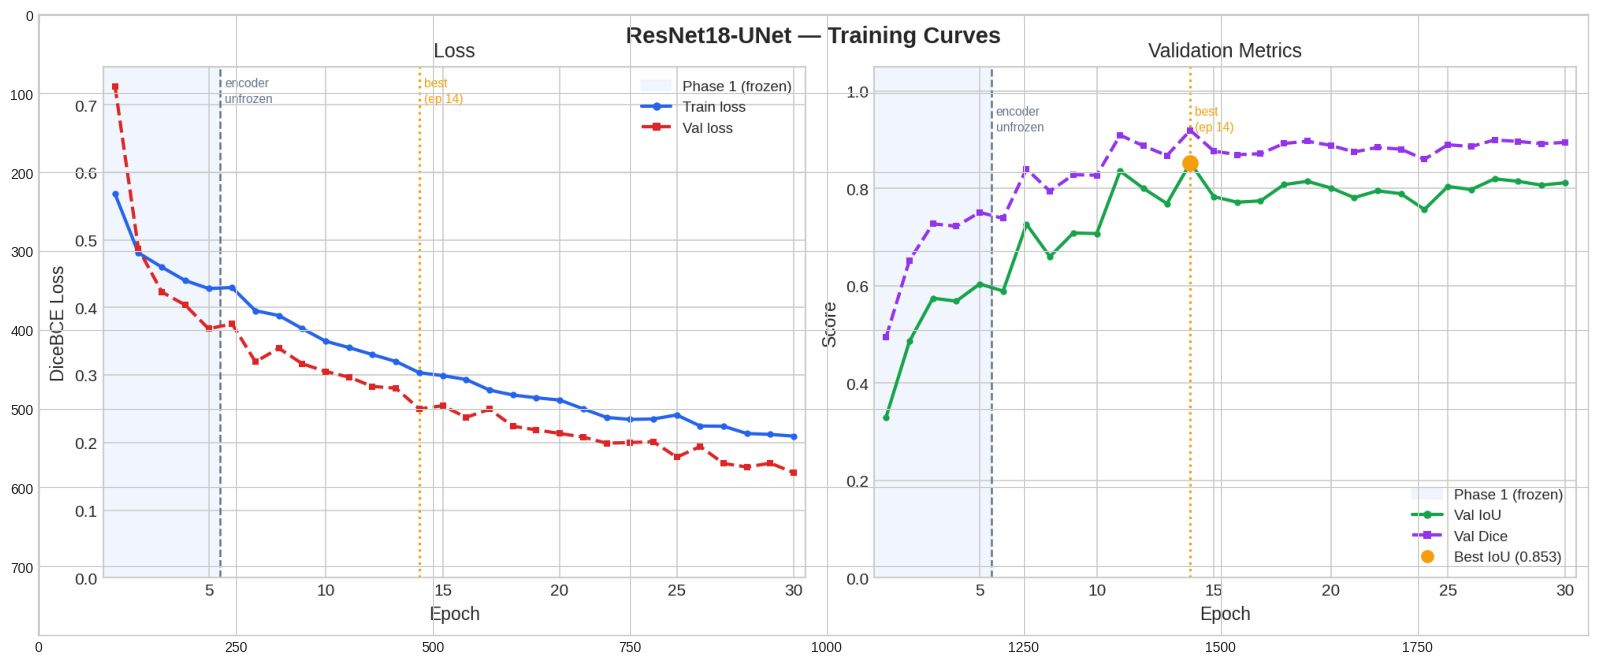

In [ ]:
training_curves_path = "/content/training_curves.png"
plot_saved_img(img_path=training_curves_path)

In [ ]:
def plot_predictions(
    model:     ResNet18UNet,
    loader:    DataLoader,
    device:    str,
    n:         int = 5,
    save_path: str = "predictions.png",
) -> None:
    """
    Plot n samples in a (n rows × 3 cols) grid:
      col 0 — Ground Truth Mask
      col 1 — Original Image   (ImageNet denormalised)
      col 2 — Predicted Mask   (threshold = 0.5)

    Parameters
    ----------
    model     : Trained ResNet18UNet instance.
    loader    : Any DataLoader whose dataset returns (image, mask) pairs
                with ImageNet-normalised images.
    device    : "cuda" or "cpu".
    n         : Number of samples to display (default 5).
    save_path : Output PNG file path.
    """
    # ── ImageNet inverse-normalisation ────────────────────────────────────────
    # The stored tensors were normalised with mean/std below; we reverse that
    # so the displayed image looks like an actual chest X-ray, not noise.
    _mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    _std  = torch.tensor(IMAGENET_STD ).view(3, 1, 1)

    def _denorm(t: torch.Tensor) -> np.ndarray:
        """[3,H,W] normalised tensor → [H,W,3] uint8 numpy array."""
        img = t.cpu() * _std + _mean          # reverse normalisation
        img = img.clamp(0.0, 1.0)             # clip numerical drift
        return (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # ── Collect n samples ─────────────────────────────────────────────────────
    model.eval()
    images_out, gt_masks, pred_masks = [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            preds  = model(images)             # [B, 1, H, W], values in (0,1)

            for i in range(images.size(0)):
                if len(images_out) >= n:
                    break
                images_out.append(_denorm(images[i]))
                gt_masks.append(masks[i, 0].numpy())           # [H, W]
                pred_masks.append((preds[i, 0].cpu().numpy() > 0.5).astype(np.uint8))

            if len(images_out) >= n:
                break

    actual_n = len(images_out)   # may be < n if loader has fewer samples

    # ── Build figure ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        actual_n, 3,
        figsize=(9, actual_n * 3),
        constrained_layout=True,
    )

    # Normalise axes to 2-D array even when actual_n == 1
    if actual_n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["Ground Truth Mask", "Original Image", "Predicted Mask"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=11, fontweight="bold", pad=6)

    for row in range(actual_n):
        # Col 0 — ground truth mask (greyscale binary)
        axes[row, 0].imshow(gt_masks[row],   cmap="gray", vmin=0, vmax=1)
        # Col 1 — original X-ray (RGB after denorm; appears greyscale, which is correct)
        axes[row, 1].imshow(images_out[row])
        # Col 2 — predicted mask (greyscale binary)
        axes[row, 2].imshow(pred_masks[row], cmap="gray", vmin=0, vmax=1)

        # Row label on the left
        axes[row, 0].set_ylabel(f"Sample {row + 1}", fontsize=9, labelpad=4)

        for col in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    fig.suptitle("ResNet18-UNet — Prediction Samples", fontsize=13, fontweight="bold")
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[plot] Prediction grid saved → {save_path}")

In [ ]:
# Load best model checkpoint
model_chkpt = torch.load("/content/resnet18_unet_best.pth")
model = ResNet18UNet(pretrained=True)
model.load_state_dict(model_chkpt["state_dict"]) # update weights
model.to(CFG["device"])

# Load dataloader
train_loader, val_loader, test_loader = build_dataloaders(root=Path(CFG["data_dir"]))


plot_predictions(
        model     = model,
        loader    = test_loader,
        device    = CFG["device"],
        n         = 5,
        save_path = "predictions.png",
    )

2026-04-10 01:14:06.100 | INFO     | __main__:build_dataloaders:114 - [data] Split → train: 96, val: 20, test: 22


[plot] Prediction grid saved → predictions.png


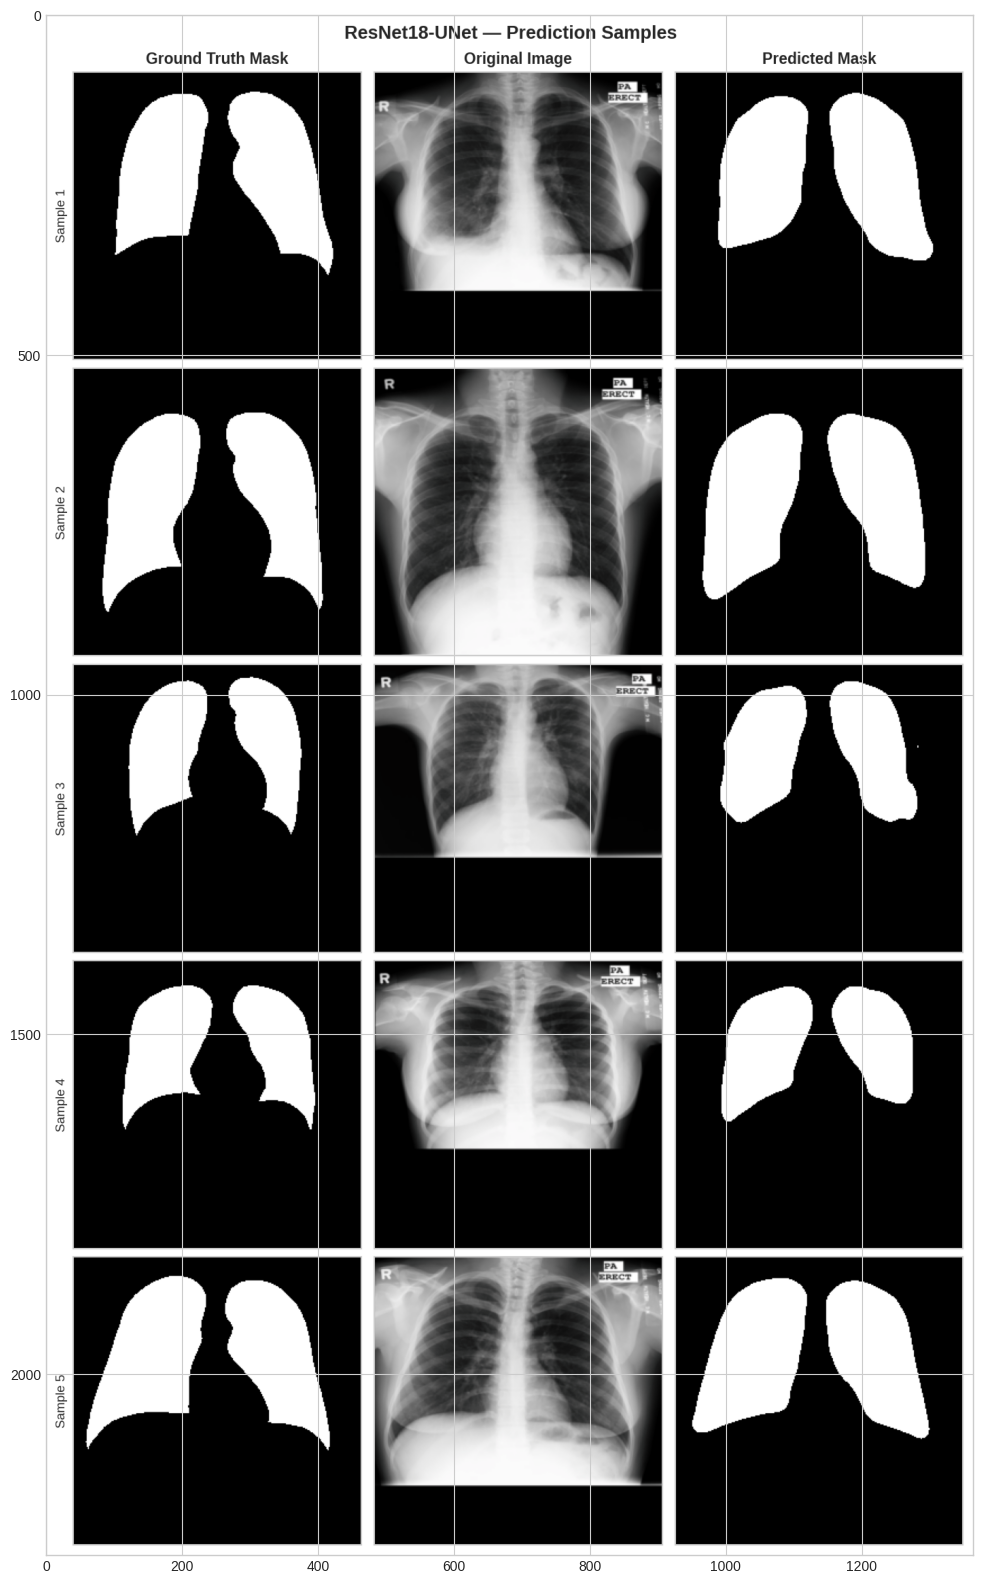

In [ ]:
predictions_img_path = "/content/predictions.png"
plot_saved_img(predictions_img_path)